# Topic 1 — Wrapper Methods
**Covers:** Recursive Feature Elimination (RFE) · Forward/backward selection · Computational
cost · Model dependency

**The story:** You've just joined **InstaMetrics**, a Mumbai-based social media analytics
startup. Your first task: help creators understand what actually makes a post **go viral**, by
building a clean, minimal feature set a model can genuinely trust — instead of throwing every
column you can measure at it.

**Dataset:** `data/raw/instagram_posts.csv` — 1,400 real-feeling Instagram posts from 220
creators, with genuinely predictive columns, a redundant duplicate, and pure-noise columns
mixed in on purpose, so wrapper methods have real junk to catch.

---
## Explanation

Imagine you're picking your squad for a treasure hunt, and you can only bring a few friends.
Last time (filter methods, Unit 2) we picked friends using quick rules without actually
playing the game. This time, we're going to actually RUN practice treasure hunts with
different squads and see who really finds the treasure fastest.

- **Recursive Feature Elimination (RFE)** = start with your WHOLE friend group, run a practice
  hunt, figure out who contributed the LEAST, and ask them to sit out next round. Repeat until
  only your best squad remains.
- **Forward selection** = the opposite: start with NO friends, add the single best one, then
  keep adding whoever helps the most next, until adding more doesn't help anymore.
- **Backward selection** = start with everyone and remove the least helpful friend one at a
  time, same idea as RFE but stopping at a chosen squad size.
- **Computational cost** = running lots of practice hunts with different squads takes way more
  time than just eyeballing your friends once. Thorough, but slow.
- **Model dependency** = a treasure hunt judged on SPEED might pick a different squad than one
  judged on TEAMWORK — the "best" squad depends on what you're actually testing them with.

## 1. WHY — Why go beyond a quick eyeball check?

Filter methods (variance, correlation, chi-square, ANOVA, mutual information — Unit 2) score
each column independently, fast, without ever training a real model. But they never answer the
question a data scientist actually cares about: **does MY specific model get better when I
combine these columns together?** Wrapper methods answer that directly, by repeatedly training
a real model on different feature subsets and keeping whichever subset actually performs best.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/instagram_posts.csv")
print(df.shape)
df[["post_id", "creator_follower_count", "is_reel", "hashtag_count", "posting_hour",
    "went_viral"]].head()

(1400, 23)


,post_id,creator_follower_count,is_reel,hashtag_count,posting_hour,went_viral
0,20018,1587,0,10,20,1
1,20099,21512,0,8,19,0
2,20790,218677,1,9,22,0
3,20631,58990,1,8,21,0
4,20811,7438,0,8,17,0


## 2. Setting up the prediction task

**Goal:** predict `went_viral` (1 = the post outperformed ~82% of posts on a virality score,
0 = it didn't) from post-level features available BEFORE a post goes live — the kind of
prediction a creator would want *before* hitting "post," not after.

We deliberately include a redundant duplicate (`creator_follower_count_copy`) and two pure-noise
columns (`random_noise_1`, `random_noise_2_device`) alongside the genuinely useful features, so
we can watch wrapper methods correctly discard them.

In [2]:
from sklearn.preprocessing import LabelEncoder

work = df.copy()
work["log_followers"] = np.log1p(work["creator_follower_count"])
work["log_followers_copy"] = np.log1p(work["creator_follower_count_copy"])
work["device_enc"] = LabelEncoder().fit_transform(work["random_noise_2_device"])

feature_cols = [
    "log_followers", "log_followers_copy", "is_reel", "video_duration_sec", "posting_hour",
    "hashtag_count", "num_mentions", "caption_length", "random_noise_1", "device_enc",
]
X = work[feature_cols]
y = work["went_viral"]

print("Feature columns:", feature_cols)
print("Viral rate:", y.mean().round(3))

Feature columns: ['log_followers', 'log_followers_copy', 'is_reel', 'video_duration_sec', 'posting_hour', 'hashtag_count', 'num_mentions', 'caption_length', 'random_noise_1', 'device_enc']
Viral rate: 0.18


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)
X_train_scaled.head()

,log_followers,log_followers_copy,is_reel,video_duration_sec,posting_hour,hashtag_count,num_mentions,caption_length,random_noise_1,device_enc
749,-0.899418,-0.899324,1.079328,1.163188,-0.362040,2.319361,0.704388,1.280886,0.115535,-1.183501
995,1.722026,1.722513,1.079328,1.918235,-0.067584,0.983837,0.704388,0.843268,1.216824,0.924516
215,-1.707560,-1.711871,1.079328,0.861170,1.699147,0.983837,1.628897,-1.344820,-0.033063,0.924516
247,1.083134,1.083276,-0.926503,-0.815033,1.257464,-1.687213,-0.220121,1.543456,0.165158,-1.183501
439,0.383439,0.383273,1.079328,1.548262,-0.362040,-0.017807,2.553407,0.755745,0.230295,0.924516


## 3. Recursive Feature Elimination (RFE) — WHY / WHAT / HOW

**Manual walk-through of the logic (toy example, 4 features):**
```
Round 1: fit model on [A, B, C, D] -> rank importances -> D is weakest -> drop D
Round 2: fit model on [A, B, C]    -> rank importances -> C is weakest -> drop C
Round 3: fit model on [A, B]       -> stop (target: keep 2 features)
Final selected: [A, B]
```
Each round the model is RE-TRAINED from scratch on the remaining features — that repeated
re-training is exactly what makes RFE a "wrapper" method, and exactly why it costs more than a
filter method's single pass.

In [4]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
rfe = RFE(estimator=model, n_features_to_select=5)
rfe.fit(X_train_scaled, y_train)

ranking = pd.DataFrame({
    "feature": feature_cols,
    "selected": rfe.support_,
    "rank": rfe.ranking_,   # 1 = selected; higher = eliminated earlier
}).sort_values("rank")
ranking

,feature,selected,rank
0,log_followers,True,1
1,log_followers_copy,True,1
2,is_reel,True,1
4,posting_hour,True,1
5,hashtag_count,True,1
8,random_noise_1,False,2
3,video_duration_sec,False,3
7,caption_length,False,4
6,num_mentions,False,5
9,device_enc,False,6


**What to look for:** the genuinely predictive features (`log_followers`, `is_reel`,
`posting_hour`, `hashtag_count`) should rank near the top, while the two pure-noise columns
(`random_noise_1`, `device_enc`) should rank lowest — RFE clearly separates real signal from
noise.

**⚠️ A more subtle, honest finding:** run this yourself and you'll likely see RFE keep **both**
`log_followers` AND its redundant duplicate `log_followers_copy`. This isn't a bug — it's a
real limitation worth understanding. With a *linear* model, two highly correlated features can
each retain a moderate, still-useful-looking coefficient (the model just splits credit between
them), so eliminating either ONE individually barely hurts performance, and RFE only ever
removes one feature at a time based on that immediate impact. RFE is good at catching **noise**
(a column with no relationship to the target), but it does **not reliably catch redundancy**
the way correlation filtering (Unit 2, Topic 5) does. This is exactly why the recommended
real-world workflow is **filter first, then wrap**: run correlation filtering to drop obvious
duplicates BEFORE handing the reduced set to RFE, rather than relying on RFE alone to catch
every kind of problem column.

## 4. RFECV — letting the model choose HOW MANY features to keep

Plain RFE needs `n_features_to_select` fixed in advance. **RFECV** cross-validates performance
at every possible feature-set size and automatically picks the size that performs best.

RFECV automatically chose 6 features out of 10
Selected: [np.str_('log_followers'), np.str_('log_followers_copy'), np.str_('is_reel'), np.str_('posting_hour'), np.str_('hashtag_count'), np.str_('random_noise_1')]


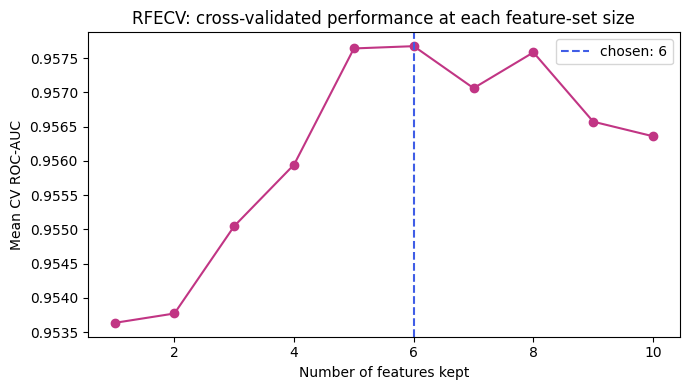

In [5]:
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt

rfecv = RFECV(estimator=LogisticRegression(max_iter=1000), min_features_to_select=1,
              cv=5, scoring="roc_auc")
rfecv.fit(X_train_scaled, y_train)

print(f"RFECV automatically chose {rfecv.n_features_} features out of {len(feature_cols)}")
print("Selected:", list(np.array(feature_cols)[rfecv.support_]))

cv_scores = rfecv.cv_results_["mean_test_score"]
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cv_scores) + 1), cv_scores, marker="o", color="#C13584")  # instagram-ish pink
plt.axvline(rfecv.n_features_, color="#405DE6", linestyle="--", label=f"chosen: {rfecv.n_features_}")
plt.xlabel("Number of features kept"); plt.ylabel("Mean CV ROC-AUC")
plt.title("RFECV: cross-validated performance at each feature-set size")
plt.legend(); plt.tight_layout(); plt.show()

## 5. Forward selection — WHY / WHAT / HOW

**Manual walk-through:**
```
Round 1: try each single feature alone -> best single feature = log_followers -> keep it
Round 2: try log_followers + each remaining -> best pair adds hashtag_count -> keep it
Round 3: try [log_followers, hashtag_count] + each remaining -> best triple adds is_reel
... continue until adding more doesn't improve validation performance
```
Forward selection BUILDS UP from nothing, the mirror image of RFE's trimming down from
everything.

In [6]:
from sklearn.feature_selection import SequentialFeatureSelector

sfs_forward = SequentialFeatureSelector(
    LogisticRegression(max_iter=1000), n_features_to_select=5,
    direction="forward", scoring="roc_auc", cv=5,
)
sfs_forward.fit(X_train_scaled, y_train)
print("Forward-selected features:", list(np.array(feature_cols)[sfs_forward.get_support()]))

Forward-selected features: [np.str_('log_followers'), np.str_('log_followers_copy'), np.str_('is_reel'), np.str_('posting_hour'), np.str_('hashtag_count')]


## 6. Backward selection — WHY / WHAT / HOW

The mirror of forward selection: start with everything, remove the single least-useful feature
each round based on real cross-validated performance, until reaching the target count.

In [7]:
sfs_backward = SequentialFeatureSelector(
    LogisticRegression(max_iter=1000), n_features_to_select=5,
    direction="backward", scoring="roc_auc", cv=5,
)
sfs_backward.fit(X_train_scaled, y_train)
print("Backward-selected features:", list(np.array(feature_cols)[sfs_backward.get_support()]))

Backward-selected features: [np.str_('log_followers_copy'), np.str_('video_duration_sec'), np.str_('posting_hour'), np.str_('hashtag_count'), np.str_('caption_length')]


## 7. Computational cost — measuring it directly

Let's actually TIME every wrapper approach against a filter method (ANOVA F-test) doing the
equivalent job.

In [8]:
import time
from sklearn.feature_selection import f_classif, SelectKBest

timings = {}

start = time.time(); SelectKBest(f_classif, k=5).fit(X_train_scaled, y_train)
timings["Filter (ANOVA F-test)"] = time.time() - start

start = time.time(); RFE(LogisticRegression(max_iter=1000), n_features_to_select=5).fit(X_train_scaled, y_train)
timings["Wrapper: RFE (fixed k=5)"] = time.time() - start

start = time.time(); RFECV(LogisticRegression(max_iter=1000), cv=5, scoring="roc_auc").fit(X_train_scaled, y_train)
timings["Wrapper: RFECV (auto k)"] = time.time() - start

start = time.time()
SequentialFeatureSelector(LogisticRegression(max_iter=1000), n_features_to_select=5,
                           direction="forward", cv=5).fit(X_train_scaled, y_train)
timings["Wrapper: Forward selection"] = time.time() - start

start = time.time()
SequentialFeatureSelector(LogisticRegression(max_iter=1000), n_features_to_select=5,
                           direction="backward", cv=5).fit(X_train_scaled, y_train)
timings["Wrapper: Backward selection"] = time.time() - start

for method, seconds in timings.items():
    print(f"{method:32s} {seconds:.3f} sec")

Filter (ANOVA F-test)            0.002 sec
Wrapper: RFE (fixed k=5)         0.014 sec
Wrapper: RFECV (auto k)          0.187 sec
Wrapper: Forward selection       0.617 sec
Wrapper: Backward selection      0.723 sec


Even on this modest dataset (1,400 posts, 10 candidate features), every wrapper method
already takes noticeably longer than the filter method, because they re-train a model many
times instead of computing one statistic per column. At InstaMetrics' real scale — millions of
posts, hundreds of candidate features — forward/backward selection would become impractically
slow (their cost scales roughly quadratically with the number of candidate features).

## 8. Model dependency — WHY the "best" features change with the model

Logistic Regression looks for features with a roughly LINEAR relationship to the log-odds of
`went_viral`. A tree-based model like Random Forest captures non-linear, threshold-based
patterns instead. Wrapping around a different model can genuinely select a different subset.

In [9]:
from sklearn.ensemble import RandomForestClassifier

rfe_rf = RFE(estimator=RandomForestClassifier(n_estimators=200, random_state=42),
             n_features_to_select=5)
rfe_rf.fit(X_train, y_train)  # tree-based models don't need scaling

comparison = pd.DataFrame({
    "feature": feature_cols,
    "selected_by_LogReg_RFE": rfe.support_,
    "selected_by_RandomForest_RFE": rfe_rf.support_,
})
comparison

,feature,selected_by_LogReg_RFE,selected_by_RandomForest_RFE
0,log_followers,True,True
1,log_followers_copy,True,True
2,is_reel,True,False
3,video_duration_sec,False,True
4,posting_hour,True,True
5,hashtag_count,True,False
6,num_mentions,False,False
7,caption_length,False,False
8,random_noise_1,False,True
9,device_enc,False,False


If the two columns disagree on some features, that's model dependency in action — RFE's
answer is only ever "the best subset **for this specific model**," never a universal truth
about the data itself.

**⚠️ Look closely at `random_noise_1`:** the Random Forest version of RFE may well have KEPT
it, while Logistic Regression correctly dropped it. This is a well-documented, real limitation
of tree-based feature importance, not a fluke: scikit-learn's default Random Forest importance
(*mean decrease in impurity*) is systematically **biased toward continuous, high-cardinality
features** — a smooth random-noise column gives the tree many more candidate split points to
exploit by chance than a low-cardinality column like `is_reel` (0/1) or `device_enc` (3
categories), even when the noise column has zero true relationship to the target. This exact
issue is why the next notebook (Embedded Methods) introduces **permutation importance** and
**stability selection** as more trustworthy alternatives — a preview of a real, recurring
problem in production feature selection, not a one-off mistake in this dataset.

## 9. Recap

- **RFE** trims the full feature set down, one weakest-feature-at-a-time, using a real model.
- **RFECV** additionally cross-validates to auto-pick the best feature COUNT, not just the
  ranking.
- **Forward/backward selection** build up or trim down, evaluating actual validated performance
  at each step.
- Wrapper methods cost noticeably more compute than filter methods, and scale worse with more
  candidate features.
- The "best" feature subset is tied to the specific model wrapped around it — a different model
  can select a genuinely different subset.

**ELI5 recap:** run real practice treasure hunts (not just eyeballing your friend group);
trim your squad down from everyone (RFE), or build it up from no one (forward selection); doing
this properly takes more time than a quick glance; and a speed-judge and a teamwork-judge might
pick different squads.